# 🏠 Advanced House Price Prediction Engine
### Objective: Build a high-performance machine learning pipeline to estimate residential property values.

This notebook follows the **End-to-End** workflow from raw data to a production-ready model. We will use **XGBoost**, a powerful gradient-boosting algorithm, combined with smart feature engineering and target transformations.

## 🛠️ Step 1: The Setup
We begin by assembling our specialized tools for data science and machine learning.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from xgboost import XGBRegressor

print("✅ Tools are ready to go!")

✅ Tools are ready to go!


## 🏠 Step 2: Knowing the Data
Let's load the dataset and take a quick look under the hood.

In [36]:
df = pd.read_csv('train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [37]:
print(df['GrLivArea'])

0       1710
1       1262
2       1786
3       1717
4       2198
        ... 
1455    1647
1456    2073
1457    2340
1458    1078
1459    1256
Name: GrLivArea, Length: 1460, dtype: int64


## 🧹 Step 3: Cleaning the Noise
Real-world data is messy. Huge houses with unusual floor plans can mislead our model. We will remove houses over 4,000 sq ft to keep our patterns clear.

In [38]:
# Drop ID as it's just a label, not a relevant feature
df = df.drop(columns=['Id'], errors='ignore')

# Removing extreme outliers (>4000 sq ft)
df = df[df['GrLivArea'] < 4000]
print(f"New dataset size: {df.shape}")

New dataset size: (1456, 80)


## 📈 Step 4: The Log-Transform Secret
House prices can vary wildly (from $40k to $700k). This 'skewness' makes it hard for standard math to guess right. 
**Solution:** We use `log1p` to scale the prices down. This focuses the model on percentage errors rather than absolute dollar errors.

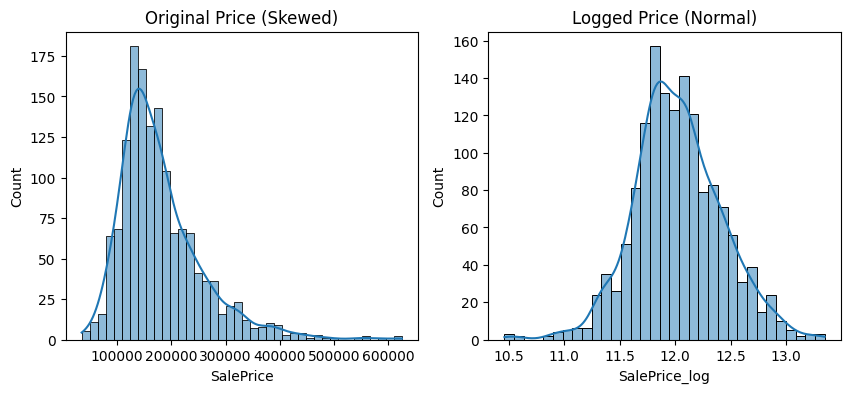

In [39]:
df['SalePrice_log'] = np.log1p(df['SalePrice'])

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['SalePrice'], kde=True).set_title("Original Price (Skewed)")
plt.subplot(1, 2, 2)
sns.histplot(df['SalePrice_log'], kde=True).set_title("Logged Price (Normal)")
plt.show()

## 🏗️ Step 5: Building Features & Splitting
We separate the columns into *inputs* (Quality, Area, etc.) and our *target* (Logged Price).

In [40]:
X = df.drop(['SalePrice', 'SalePrice_log'], axis=1)
y = df['SalePrice_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data split into Train and Test sets.")

Data split into Train and Test sets.


## ⚡ Step 6: The XGBoost Pipeline
We bundle everything into one single pipeline. This manages missing data, encodes text categories, and handles the learning logic in one move.

In [41]:
# Identifying numerical and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Pipeline: Cleaning numerical features
num_transformer = Pipeline([('imputer', SimpleImputer(strategy='median'))])

# Pipeline: Cleaning & Encoding categorical features
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=5, subsample=0.8, random_state=42))
])

print("Brain is ready. Starting training...")
model.fit(X_train, y_train)

print("Training Complete!")

Brain is ready. Starting training...
Training Complete!


In [42]:
print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'Bs...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
              

## 🏆 Step 7: How Good Are We?
We evaluate the model using R-Squared and RMSE, then convert the logged predictions back to real dollars.

R-Squared Score: 0.9062


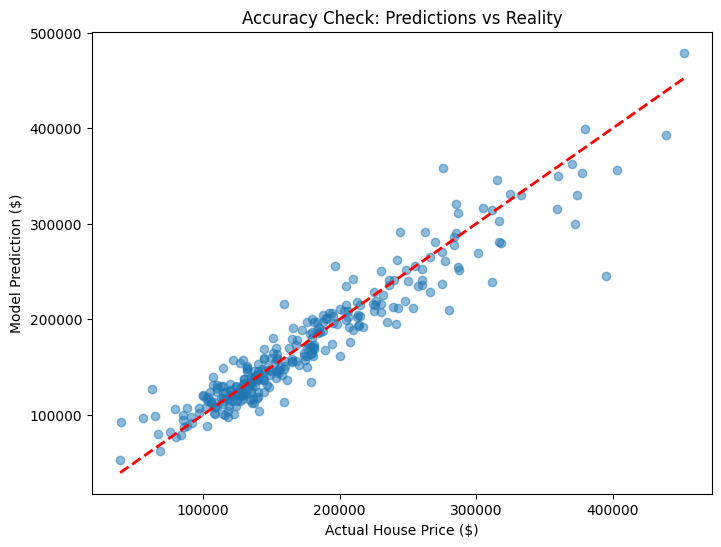

In [49]:
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log) # Reverse the log transform
y_test_dollars = np.expm1(y_test)

r2 = r2_score(y_test_dollars, y_pred)
print(f"R-Squared Score: {r2:.4f}")

# Visualizing Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test_dollars, y_pred, alpha=0.5)
plt.plot([y_test_dollars.min(), y_test_dollars.max()], [y_test_dollars.min(), y_test_dollars.max()], 'r--', lw=2)
plt.xlabel("Actual House Price ($)")
plt.ylabel("Model Prediction ($)")
plt.title("Accuracy Check: Predictions vs Reality")
plt.show()